In [16]:
import os
os.add_dll_directory("C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/bin")
os.add_dll_directory("C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/libnvvp")

<AddedDllDirectory('C:/Program Files/NVIDIA GPU Computing Toolkit/CUDA/v11.2/libnvvp')>

In [17]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6738526689298729592
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 2232156160
locality {
  bus_id: 1
  links {
  }
}
incarnation: 804513888942921204
physical_device_desc: "device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5"
xla_global_id: 416903419
]


In [18]:
# Menginstal paket Kaggle
!pip install kaggle -q

# Mengunduh dataset baru
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
# Mengekstrak file zip yang diunduh
import zipfile
with zipfile.ZipFile('garbage-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('garbage_data')

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\aqilw\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\tensorflow\\compiler\\tf2tensorrt\\_pywrap_py_utils.pyd'
Consider using the `--user` option or check the permissions.



Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Epoch 1/10
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002413EE5E440>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002413EE5E440>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compat

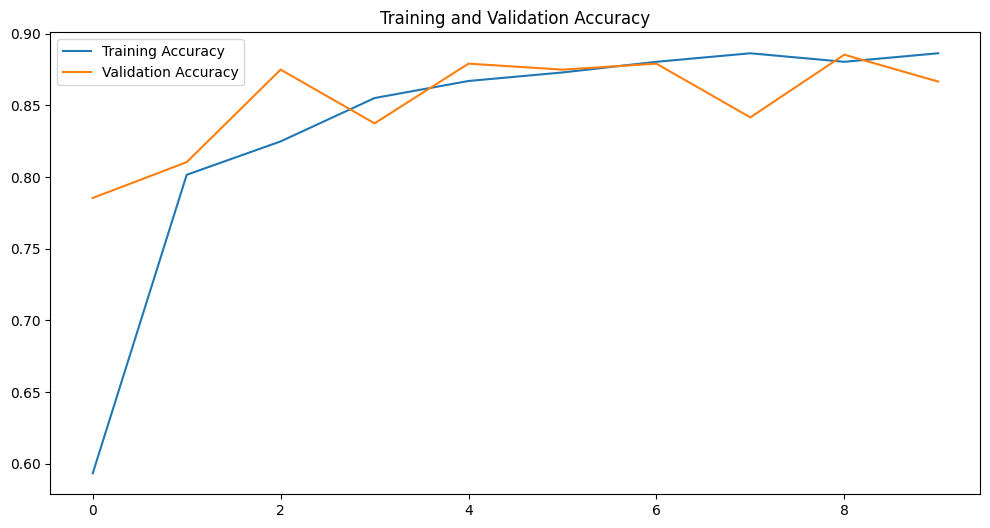

In [21]:
# Install dependencies (if not already installed)
!pip install -q tensorflow tensorflow-addons tf-slim opencv-python-headless

# Import necessary libraries
import os
import numpy as np
import tensorflow as tf
import cv2
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Model
from keras.applications import EfficientNetB2
from keras.applications.efficientnet import preprocess_input
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tqdm import tqdm

# Step 1: Prepare Dataset
dataset_path = "garbage_data/Garbage classification/Garbage classification"
classes = os.listdir(dataset_path)
print("Classes:", classes)

# Prepare the dataset paths and labels
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

# Create a DataFrame
import pandas as pd
data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

# Split dataset
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)

# Image preprocessing and augmentation
IMG_SIZE = 224
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

def augment_image(img):
    # Example: Augmentations (flip, rotation)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.rot90(img)
    return img

# Step 2: Data Generators
def data_generator(data, batch_size=32, augment=False):
    while True:
        batch_data = data.sample(batch_size)
        batch_images, batch_labels = [], []
        for _, row in batch_data.iterrows():
            img = preprocess_image(row['image_path'])
            label = row['label']
            if augment:
                img = augment_image(img)
            batch_images.append(img)
            batch_labels.append(label)
        yield np.array(batch_images), np.array(batch_labels)

train_gen = data_generator(train_df, batch_size=32, augment=True)
test_gen = data_generator(test_df, batch_size=32)

# Step 3: Build Classification Model with EfficientNet-B2
base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model initially
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Step 4: Train the Model
history = model.fit(train_gen,
                    steps_per_epoch=len(train_df)//32,
                    validation_data=test_gen,
                    validation_steps=len(test_df)//32,
                    epochs=10)

# Step 5: Evaluate the Model
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=classes))

# Precision, Recall, F1-Score
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, predicted_labels, average='weighted')
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")

# Plot Training Accuracy and Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

Epoch 1/15
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x00000242B40FBAC0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x00000242B40FBAC0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. O

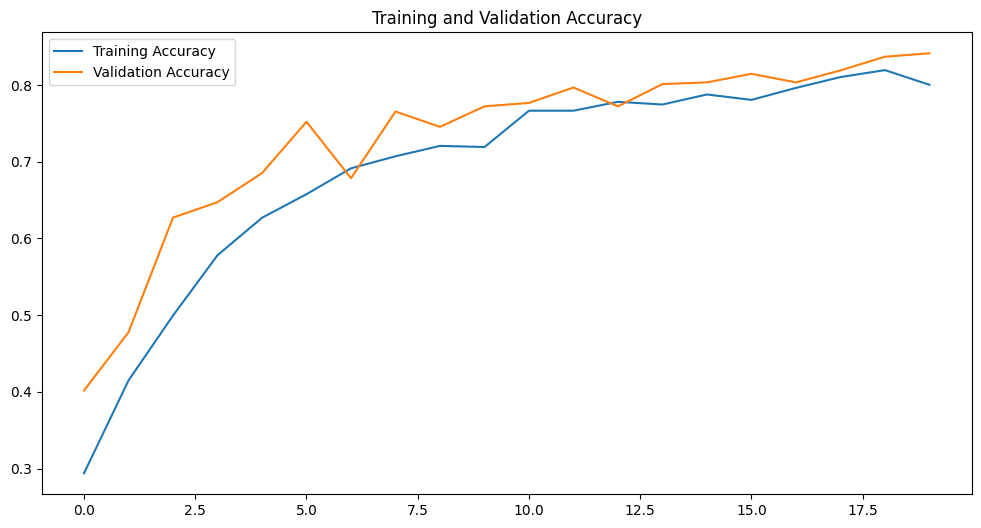

In [22]:
# Hyperparameter Adjustments
BATCH_SIZE = 64
IMG_SIZE = 224
EPOCHS = 15
INITIAL_LR = 1e-4

# Enhanced Augmentation
def augment_image(img):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    return img

# Data Generator Function
def data_generator(data, batch_size=BATCH_SIZE, augment=False):
    while True:
        batch_data = data.sample(batch_size)
        batch_images, batch_labels = [], []
        for _, row in batch_data.iterrows():
            img = preprocess_image(row['image_path'])
            if augment:
                img = augment_image(img)
            batch_images.append(img)
            batch_labels.append(row['label'])
        yield np.array(batch_images), np.array(batch_labels)

train_gen = data_generator(train_df, batch_size=BATCH_SIZE, augment=True)
test_gen = data_generator(test_df, batch_size=BATCH_SIZE)

# Load Pretrained EfficientNetB2 Model
base_model = EfficientNetB2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(len(classes), activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

# Freeze Base Model Layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the Model
model.compile(optimizer=Adam(learning_rate=INITIAL_LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Callbacks: Early Stopping and LR Scheduler
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, min_lr=1e-6)
]

# Train the Model
history = model.fit(train_gen,
                    steps_per_epoch=len(train_df) // BATCH_SIZE,
                    validation_data=test_gen,
                    validation_steps=len(test_df) // BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=callbacks)

# Unfreeze Some Layers for Fine-Tuning
for layer in base_model.layers[-20:]:  # Unfreeze the last 20 layers
    layer.trainable = True

# Recompile with Lower LR for Fine-Tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Fine-Tune the Model
history_fine = model.fit(train_gen,
                         steps_per_epoch=len(train_df) // BATCH_SIZE,
                         validation_data=test_gen,
                         validation_steps=len(test_df) // BATCH_SIZE,
                         epochs=5,
                         callbacks=callbacks)

# Evaluate the Model
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=classes))

# Plot Training and Validation Metrics
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


2/2 [==============================] - 0s 120ms/step


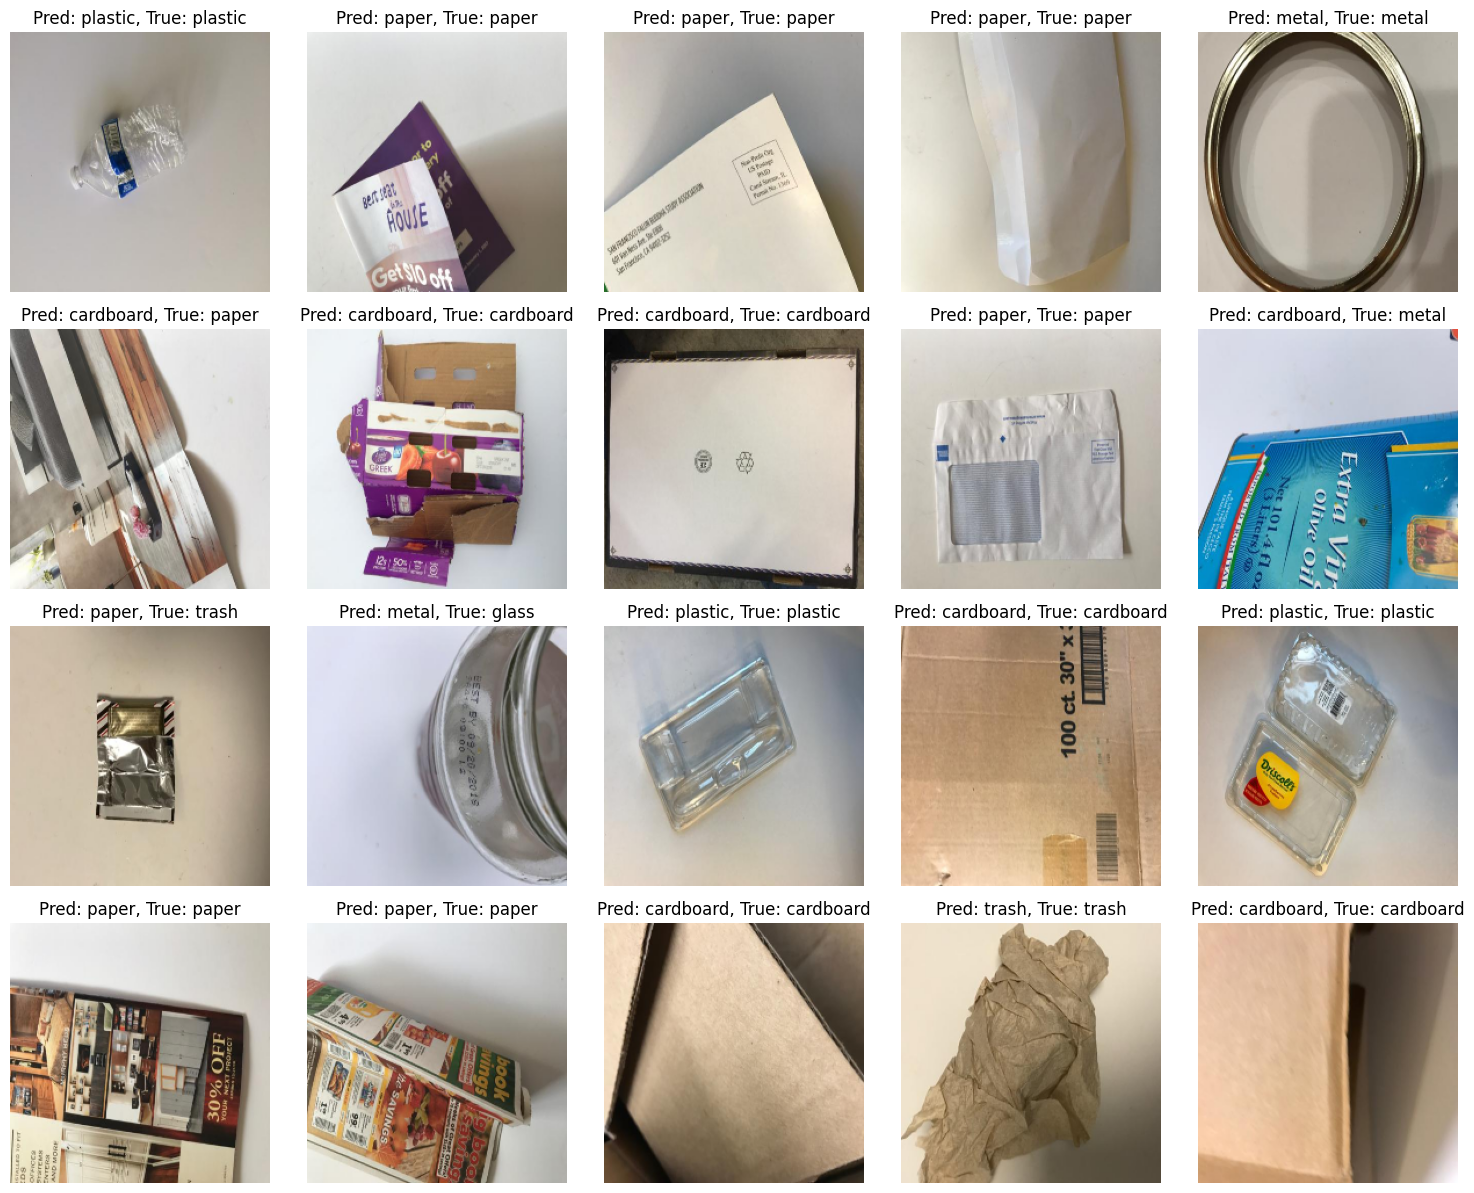

In [23]:
import matplotlib.pyplot as plt

# Visualize Predictions
def visualize_predictions(test_images, test_labels, predicted_labels, class_names, num_images=20):
    plt.figure(figsize=(15, 15))
    for i in range(num_images):
        ax = plt.subplot(5, 5, i + 1)
        img = test_images[i].astype("uint8")
        true_label = class_names[test_labels[i]]
        pred_label = class_names[predicted_labels[i]]
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}, True: {true_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Use the first batch of test images
test_images, test_labels = next(test_gen)
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Class Names (based on dataset folders)
class_names = classes

# Visualize
visualize_predictions(test_images, test_labels, predicted_labels, class_names, num_images=20)


In [24]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_2 (Rescaling)        (None, 224, 224, 3)  0           ['input_2[0][0]']                
                                                                                                  
 normalization_1 (Normalization  (None, 224, 224, 3)  7          ['rescaling_2[0][0]']            
 )                                                                                                
                                                                                            

In [25]:
# from tensorflow.keras.utils import plot_model

# # Visualisasi struktur model
# plot_model(model, to_file='efficientnet_structure.png', show_shapes=True, show_layer_names=True)

In [26]:
# 2. Analisis Visualisasi Layer
# Pilih beberapa layer dari EfficientNet untuk divisualisasikan
layer_names = [layer.name for layer in base_model.layers if 'conv' in layer.name or 'pool' in layer.name]
layer_outputs = [layer.output for layer in base_model.layers if 'conv' in layer.name or 'pool' in layer.name]

# Model baru untuk visualisasi layer
visualization_model = Model(inputs=base_model.input, outputs=layer_outputs)


In [28]:
# # Pilih satu gambar dari dataset uji untuk divisualisasikan
# sample_image = preprocess_image(test_df['image_path'].iloc[0])
# sample_image = np.expand_dims(sample_image, axis=0)  # Tambahkan dimensi batch

# # Dapatkan output dari beberapa layer
# feature_maps = visualization_model.predict(sample_image)

# # Visualisasi beberapa feature maps
# for layer_name, feature_map in zip(layer_names, feature_maps):
#     if len(feature_map.shape) == 4:  # Jika feature map berbentuk (batch, height, width, channels)
#         num_channels = feature_map.shape[-1]
#         size = feature_map.shape[1]

#         plt.figure(figsize=(15, 15))
#         plt.suptitle(f"Feature Maps from Layer: {layer_name}")

#         # Plot beberapa channel pertama
#         for i in range(min(6, num_channels)):  # Batasi ke 6 channel pertama
#             plt.subplot(1, 6, i + 1)
#             plt.imshow(feature_map[0, :, :, i], cmap='viridis')
#             plt.axis('off')
#         plt.tight_layout()
#         plt.show()
